# Synthetic invoice prediction experiment: one dataset, two models

## tl;dr

On the same 128 synthetic test invoices, SAP RPT 1.6 scores **71.1% late-payment accuracy** versus **65.6% for XGBoost**. For synthetic fraud, XGBoost identifies **15 of 22** cases and RPT identifies **10 of 22**; RPT has fewer false alarms (5 versus 9). Both models use the same ten predictors and hidden test labels.

Source: `data/synthetic_invoices/payment_behavior.csv`; generator: `scripts/generate_synthetic_invoices.py`. This is an optional walkthrough. For separate runnable steps, use `xgboost_run.ipynb`, `rpt_btp_run.ipynb`, and `compare_saved_results.ipynb`.

## Context & methods

The file contains 1,152 synthetic invoices in a fixed order. The first 1,024 are XGBoost training rows and RPT context rows; the final 128 are the shared test rows. Both targets are binary (`paid_late`, `is_fraud`). Invoice IDs identify rows and are excluded from model features. RPT receives the same features, with both test targets replaced by `[PREDICT]`. XGBoost uses one-hot encoding for the two categorical predictors and fits one classifier per target.

### Key assumptions

- Labels are generated from a known noisy formula and do not represent actual customer behavior or fraud.
- The split is fixed and is not a time-based forecast or an external validation set.
- Only 22 test invoices have the fraud label, so fraud metrics are sensitive to a few predictions. The synthetic generator was configured to yield more fraud labels than the original rare-fraud scenario.
- RPT metrics come from the saved BTP response, with request and result checksums verified against its metadata. The notebook does not make a live BTP call.

### 1. Load the shared dataset

In [1]:
import hashlib
import json
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix
from IPython.display import display, Markdown

ROOT = next(path for path in (Path.cwd(), Path.cwd().parent) if (path / "data/synthetic_invoices/payment_behavior.csv").exists())
sys.path.insert(0, str(ROOT / "scripts"))
from generate_synthetic_invoices import CONTEXT_ROWS, PREDICTION_ROWS, TARGETS
from run_xgboost_invoices import load_split, train_models, predict_frame

DATA = ROOT / "data/synthetic_invoices"
invoices = pd.read_csv(DATA / "payment_behavior.csv")
train, test = load_split()
print(f"Shared input: {len(invoices)} invoices | train/context: {len(train)} | test: {len(test)}")
display(invoices.head(5))

Shared input: 1152 invoices | train/context: 1024 | test: 128


,invoice_id,invoice_amount_eur,payment_terms_days,customer_tenure_months,prior_late_payment_rate,open_invoice_count,customer_segment,region,billing_address_mismatch,bank_account_changed_recently,weekend_submission,paid_late,is_fraud
0,SYN-00001,3606.34,60,90,0.183,9,small,Nordics,0,0,1,0,0
1,SYN-00002,807.59,14,66,0.244,2,small,Southern Europe,0,0,0,0,0
2,SYN-00003,928.52,30,7,0.586,0,midmarket,Southern Europe,0,0,1,1,0
3,SYN-00004,2994.31,14,31,0.094,7,enterprise,Nordics,0,0,0,0,1
4,SYN-00005,2112.90,14,17,0.133,5,midmarket,DACH,0,0,1,0,0


### 2. Check the fair comparison split

In [2]:
rpt_input = pd.read_csv(DATA / "exports/rpt_upload.csv", dtype={target: str for target in TARGETS})
assert len(invoices) == len(rpt_input) == CONTEXT_ROWS + PREDICTION_ROWS
assert invoices.invoice_id.is_unique
assert rpt_input.drop(columns=list(TARGETS)).equals(invoices.drop(columns=list(TARGETS)))
for target in TARGETS:
    assert rpt_input[target].iloc[:CONTEXT_ROWS].astype(int).equals(train[target])
    assert rpt_input[target].iloc[CONTEXT_ROWS:].eq("[PREDICT]").all()
print("Both model inputs have identical invoice IDs and predictors; RPT test targets are hidden.")
class_counts = pd.DataFrame({target: [int(train[target].sum()), int(test[target].sum())] for target in TARGETS}, index=["Training/context", "Test"])
display(class_counts)

Both model inputs have identical invoice IDs and predictors; RPT test targets are hidden.


,paid_late,is_fraud
Training/context,450,187
Test,51,22


### 3. Inspect target balance

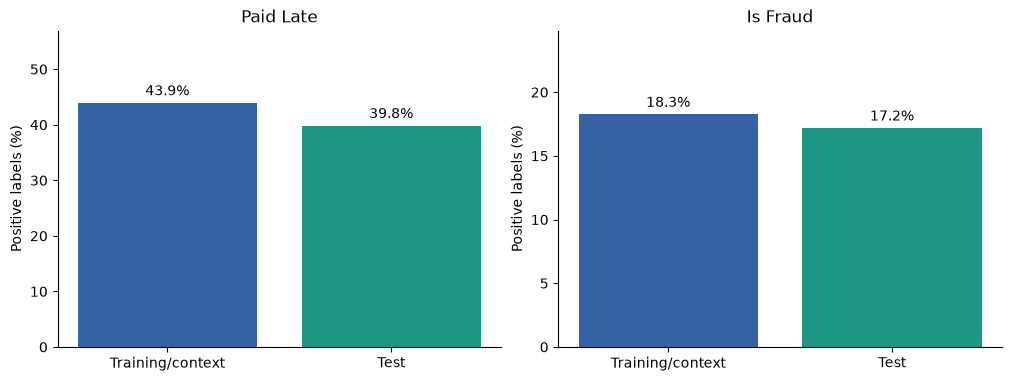

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.7), constrained_layout=True)
for ax, target in zip(axes, TARGETS):
    values = [train[target].mean() * 100, test[target].mean() * 100]
    bars = ax.bar(["Training/context", "Test"], values, color=["#3563a6", "#1d9683"])
    ax.bar_label(bars, fmt="%.1f%%", padding=3)
    ax.set_ylim(0, max(values) * 1.25 + 2)
    ax.set_ylabel("Positive labels (%)")
    ax.set_title(target.replace("_", " ").title())
    ax.spines[["top", "right"]].set_visible(False)
plt.show()

Fraud is still the minority label in both splits. Accuracy alone can hide missed fraud cases, so use the positive-case counts above as the denominators for recall.

### 4. Fit XGBoost and score the held-out invoices

In [4]:
models, feature_columns = train_models(train)
xgb_results = predict_frame(models, feature_columns, test)
assert xgb_results.invoice_id.tolist() == test.invoice_id.tolist()
rows = []
for target in TARGETS:
    y = xgb_results[f"actual_{target}"]
    predicted = xgb_results[f"predicted_{target}"]
    probability = xgb_results[f"probability_{target}"]
    rows.append({"Model": "XGBoost", "Target": target, "Positive cases": int(y.sum()),
                 "Accuracy": accuracy_score(y, predicted),
                 "Precision": precision_score(y, predicted, zero_division=0),
                 "Recall": recall_score(y, predicted, zero_division=0),
                 "ROC AUC": roc_auc_score(y, probability)})
xgb_metrics = pd.DataFrame(rows).set_index(["Model", "Target"])
display(xgb_metrics.round(3))
display(xgb_results[["invoice_id", "actual_paid_late", "predicted_paid_late", "probability_paid_late", "actual_is_fraud", "predicted_is_fraud", "probability_is_fraud"]].head(8).round(3))

Positive cases  Accuracy  Precision  Recall  ROC AUC
Model   Target                                                         
XGBoost paid_late              51     0.656      0.561   0.627    0.724
        is_fraud               22     0.875      0.625   0.682    0.804

,invoice_id,actual_paid_late,predicted_paid_late,probability_paid_late,actual_is_fraud,predicted_is_fraud,probability_is_fraud
1024,SYN-01025,1,0,0.379,0,0,0.235
1025,SYN-01026,0,0,0.347,1,1,0.842
1026,SYN-01027,0,0,0.437,0,0,0.248
1027,SYN-01028,0,0,0.433,0,0,0.216
1028,SYN-01029,1,0,0.312,0,0,0.168
1029,SYN-01030,0,0,0.123,0,0,0.134
1030,SYN-01031,0,0,0.459,0,0,0.321
1031,SYN-01032,0,0,0.047,0,0,0.095


### 5. See the correct and missed cases

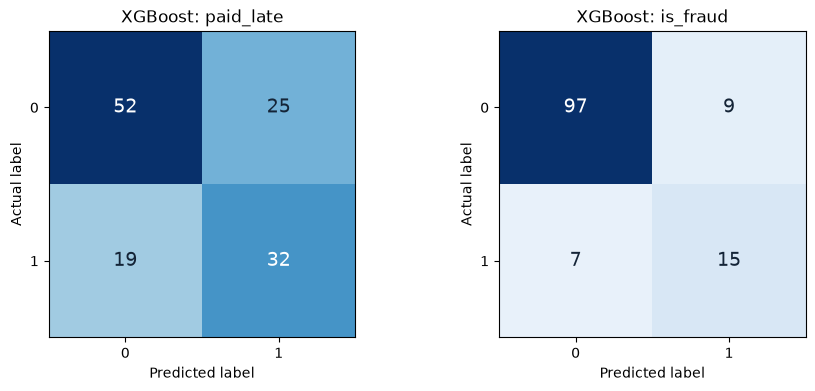

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8), constrained_layout=True)
for ax, target in zip(axes, TARGETS):
    matrix = confusion_matrix(xgb_results[f"actual_{target}"], xgb_results[f"predicted_{target}"], labels=[0, 1])
    ax.imshow(matrix, cmap="Blues", vmin=0, vmax=matrix.max())
    for (i, j), count in __import__("numpy").ndenumerate(matrix):
        ax.text(j, i, str(count), ha="center", va="center", color="white" if count > matrix.max()/2 else "#142437", fontsize=14)
    ax.set(xticks=[0, 1], yticks=[0, 1], xlabel="Predicted label", ylabel="Actual label", title=f"XGBoost: {target}")
plt.show()

For fraud, the bottom-right cell is correctly flagged fraud; the bottom-left cell is missed fraud. Because the test set has only 22 fraud-labelled invoices, inspect recall and precision alongside accuracy.

### 6. Load the saved SAP-RPT-1.6 BTP result

In [6]:
rpt_path = DATA / "rpt16_results.csv"
metadata_path = DATA / "rpt16_run_metadata.json"
rpt_metrics = None
if not rpt_path.exists():
    display(Markdown("**No saved RPT result.** Run `rpt_btp_run.ipynb` once, then rerun this notebook."))
else:
    if not metadata_path.exists():
        raise FileNotFoundError("RPT results exist without run metadata; verify their origin.")
    metadata = json.loads(metadata_path.read_text(encoding="utf-8"))
    request_path = DATA / "rpt16_request.json"
    assert metadata["source"] == "btp_deployment"
    assert metadata["request_sha256"] == hashlib.sha256(request_path.read_bytes()).hexdigest()
    assert metadata["results_sha256"] == hashlib.sha256(rpt_path.read_bytes()).hexdigest()
    rpt_results = pd.read_csv(rpt_path)
    assert len(rpt_results) == len(test) and rpt_results.invoice_id.is_unique
    assert rpt_results.invoice_id.tolist() == test.invoice_id.tolist()
    rpt_rows = []
    for target in TARGETS:
        y = rpt_results[f"actual_{target}"]
        predicted = rpt_results[f"predicted_{target}"]
        assert y.tolist() == test[target].tolist()
        assert predicted.isin([0, 1]).all()
        rpt_rows.append({"Model": "SAP-RPT-1.6 BTP", "Target": target, "Positive cases": int(y.sum()),
                         "Accuracy": accuracy_score(y, predicted),
                         "Precision": precision_score(y, predicted, zero_division=0),
                         "Recall": recall_score(y, predicted, zero_division=0),
                         "ROC AUC": float("nan")})
    rpt_metrics = pd.DataFrame(rpt_rows).set_index(["Model", "Target"])
    print(f"Verified direct BTP result from {metadata['run_at_utc']} (UTC).")
    display(rpt_metrics.round(3))

Verified direct BTP result from 2026-10-03T22:17:05.746027+00:00 (UTC).


Positive cases  Accuracy  Precision  Recall  \
Model           Target                                                   
SAP-RPT-1.6 BTP paid_late              51     0.711      0.630   0.667   
                is_fraud               22     0.867      0.667   0.455   

                           ROC AUC  
Model           Target              
SAP-RPT-1.6 BTP paid_late      NaN  
                is_fraud       NaN

### 7. Compare models on the identical test set

In [7]:
comparison = xgb_metrics if rpt_metrics is None else pd.concat([xgb_metrics, rpt_metrics])
display(comparison.round(3))
if rpt_metrics is None:
    print("Comparison is pending SAP-RPT-1.6 inference. XGBoost results alone do not establish which model performs better.")

Positive cases  Accuracy  Precision  Recall  \
Model           Target                                                   
XGBoost         paid_late              51     0.656      0.561   0.627   
                is_fraud               22     0.875      0.625   0.682   
SAP-RPT-1.6 BTP paid_late              51     0.711      0.630   0.667   
                is_fraud               22     0.867      0.667   0.455   

                           ROC AUC  
Model           Target              
XGBoost         paid_late    0.724  
                is_fraud     0.804  
SAP-RPT-1.6 BTP paid_late      NaN  
                is_fraud       NaN

## Takeaways

- The **same 128 test invoices** and **both targets** define the comparison. The main synthetic dataset has 187 fraud-labelled context rows and 22 fraud-labelled test rows.
- SAP RPT 1.6 identifies **34 of 51** late-payment cases versus **32 of 51** for XGBoost. Its late-payment accuracy, precision, and recall are higher in this run.
- For fraud, XGBoost identifies **15 of 22** cases with **9 false alarms**. RPT identifies **10 of 22** with **5 false alarms**. Show recall and false alarms together; accuracy alone hides this trade-off.
- XGBoost ROC AUC uses its class-1 probabilities. RPT ROC AUC is left blank because the saved top-1 response provides confidence for its selected class, not an explicit class-1 score for every invoice.
- These are synthetic labels on one fixed split. The results demonstrate the workflow and cannot validate a real payment or fraud decision system.

The three focused notebooks provide the publishable run order; this combined notebook is an optional walkthrough.